RAW PORTFOLIOS


,Annual Return,Annual Volatility,Sharpe Ratio,Drawdown
Equal Weight,0.073145,0.145987,0.459257,-0.416147
Inverse Vol,0.037706,0.049443,0.485823,-0.154685
Max Geo,0.112848,0.162157,0.653022,-0.393364
Max Sharpe,0.065607,0.090604,0.590159,-0.249889
Carver,0.031717,0.033757,0.520809,-0.100688
Hierarchical Inv Vol,0.033278,0.036858,0.520988,-0.102534
SPY,0.113995,0.197393,0.573694,-0.514814
60/40,0.082766,0.111126,0.643224,-0.314846
Tech,0.164291,0.224067,0.727695,-0.493668


RAW TURNOVER


,Average Turnover,Max Turnover
Equal Weight,0.013557,0.054261
Inverse Vol,0.009389,0.055962
Max Geo,0.082484,0.413810
Max Sharpe,0.117009,0.854047
Carver,0.007224,0.048100
Hierarchical Inv Vol,0.007849,0.053271
SPY,0.000000,0.000000
60/40,0.009782,0.053888
Tech,0.000000,0.000000


RAW TRANSACTION COSTS


...

,Average Leverage,Max Leverage,Min Leverage,Time at 2x
Equal Weight,0.797937,1.273660,0.393650,0.000000
Inverse Vol,1.842611,2.000000,1.430382,0.608889
Max Geo,0.628909,0.935328,0.358117,0.000000
Max Sharpe,1.595794,2.000000,0.505498,0.600000
Carver,1.992263,2.000000,1.849693,0.911111
Hierarchical Inv Vol,1.982199,2.000000,1.758244,0.884444
SPY,0.583984,0.879476,0.326304,0.000000
60/40,1.022381,1.541055,0.584533,0.000000
Tech,0.492930,0.746086,0.330335,0.000000


VOL-TARGETED TURNOVER


,Average Turnover,Max Turnover
Equal Weight,0.013804,0.181512
Inverse Vol,0.022569,0.172598
Max Geo,0.058026,0.349260
Max Sharpe,0.168103,1.309052
Carver,0.018109,0.090279
Hierarchical Inv Vol,0.019470,0.100983
SPY,0.006806,0.084163
60/40,0.014782,0.169114
Tech,0.006043,0.048023


VOL-TARGETED TRANSACTION COSTS


,Total Cost,Average Cost per Rebalance,Max Cost per Rebalance
Equal Weight,0.006212,0.000028,0.000363
Inverse Vol,0.010156,0.000045,0.000345
Max Geo,0.026112,0.000116,0.000699
Max Sharpe,0.075646,0.000336,0.002618
Carver,0.008149,0.000036,0.000181
Hierarchical Inv Vol,0.008761,0.000039,0.000202
SPY,0.003063,0.000014,0.000168
60/40,0.006652,0.000030,0.000338
Tech,0.002719,0.000012,0.000096


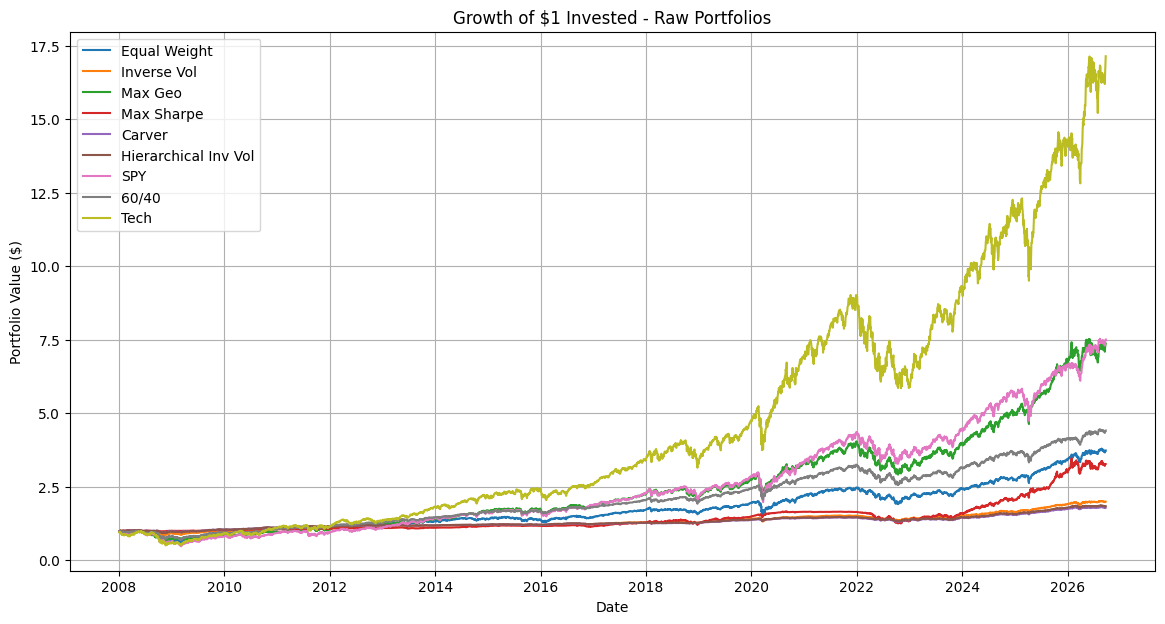

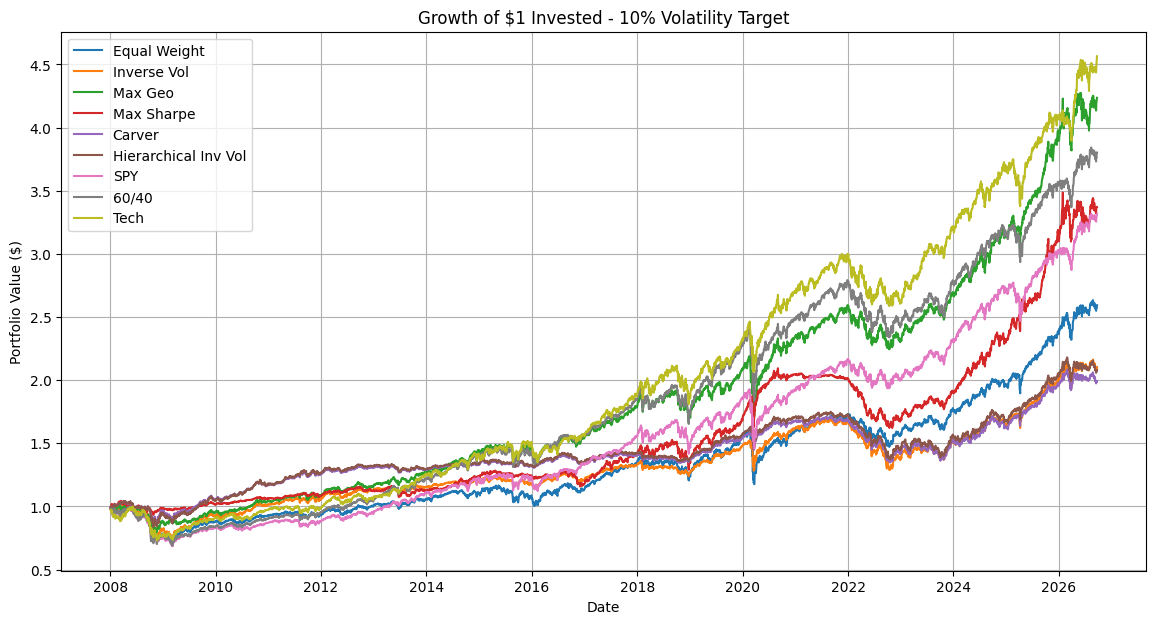

In [2]:
import sys
sys.path.append("../src")

import importlib
import pandas as pd
import matplotlib.pyplot as plt

import metrics
import allocations
import backtesting

importlib.reload(metrics)
importlib.reload(allocations)
importlib.reload(backtesting)

WINDOW = 3 * 252
STEP = 21
TRANSACTION_COST = 0.001
VOL_TARGET = 0.10
MAX_LEVERAGE = 2.0
FUNDING_SPREAD = 0.01

prices = pd.read_csv("../data/etf_prices_raw.csv", index_col="Date", parse_dates=True)
returns = metrics.compute_returns(prices)

rf_rate = pd.read_csv("../data/risk_free_rate.csv", index_col="Date", parse_dates=True)["risk_free_rate"]
rf_rate = pd.to_numeric(rf_rate, errors="coerce").ffill()

annual_rf = rf_rate / 100
risk_free_returns = (1 + annual_rf) ** (1 / 252) - 1
risk_free_returns = risk_free_returns.reindex(returns.index).ffill()

groups = {
    "equities": ["SPY", "QQQ", "EWU", "EZU", "EEM"],
    "bonds": ["IEF", "SHY"],
    "alternatives": ["GLD", "VNQ"]
}

strategies = {
    "Equal Weight": (backtesting.equal_strategy, None),
    "Inverse Vol": (backtesting.risk_strategy, None),
    "Max Geo": (backtesting.max_geo_strategy, None),
    "Max Sharpe": (backtesting.max_sharpe_strategy, None),
    "Carver": (backtesting.carver_handcrafting_strategy, groups),
    "Hierarchical Inv Vol": (backtesting.inv_handcrafting_strategy, groups),
    "SPY": (backtesting.spy_strategy, None),
    "60/40": (backtesting.sixty_forty_strategy, None),
    "Tech": (backtesting.tech_strategy, None)
}

def performance_summary(port_ret):
    return pd.Series({
        "Annual Return": metrics.annualize_returns(port_ret),
        "Annual Volatility": metrics.annualize_volatility(port_ret),
        "Sharpe Ratio": metrics.sharpe_ratio(port_ret, risk_free_returns),
        "Drawdown": metrics.drawdown(port_ret)
    })

def leverage_summary(leverage):
    return pd.Series({
        "Average Leverage": leverage.mean(),
        "Max Leverage": leverage.max(),
        "Min Leverage": leverage.min(),
        "Time at 2x": (leverage >= 2.0 - 1e-10).mean()
    })

def turnover_summary(turnover):
    return pd.Series({
        "Average Turnover": turnover.mean(),
        "Max Turnover": turnover.max()
    })

def transaction_cost_summary(costs):
    return pd.Series({
        "Total Cost": costs.sum(),
        "Average Cost per Rebalance": costs.mean(),
        "Max Cost per Rebalance": costs.max()
    })

raw_portfolio_returns = {}
raw_weight_histories = {}
raw_turnover_histories = {}
raw_transaction_cost_histories = {}

for name, (strategy, strategy_groups) in strategies.items():
    port_ret, weights, _, turnover, transaction_cost = backtesting.backtest(
        returns,
        window=WINDOW,
        step=STEP,
        allocation_func=strategy,
        groups=strategy_groups,
        vol_target=None,
        risk_free_returns=risk_free_returns,
        transaction_cost=TRANSACTION_COST,
        funding_spread=FUNDING_SPREAD
    )

    raw_portfolio_returns[name] = port_ret
    raw_weight_histories[name] = weights
    raw_turnover_histories[name] = turnover
    raw_transaction_cost_histories[name] = transaction_cost

raw_summary = pd.DataFrame({
    name: performance_summary(port_ret)
    for name, port_ret in raw_portfolio_returns.items()
}).T

raw_turnover_summary = pd.DataFrame({
    name: turnover_summary(turnover)
    for name, turnover in raw_turnover_histories.items()
}).T

raw_transaction_cost_summary = pd.DataFrame({
    name: transaction_cost_summary(costs)
    for name, costs in raw_transaction_cost_histories.items()
}).T

print("RAW PORTFOLIOS")
display(raw_summary)

print("RAW TURNOVER")
display(raw_turnover_summary)

print("RAW TRANSACTION COSTS")
display(raw_transaction_cost_summary)

targeted_portfolio_returns = {}
targeted_weight_histories = {}
targeted_leverage_histories = {}
targeted_turnover_histories = {}
targeted_transaction_cost_histories = {}

for name, (strategy, strategy_groups) in strategies.items():
    port_ret, weights, leverage, turnover, transaction_cost = backtesting.backtest(
        returns,
        window=WINDOW,
        step=STEP,
        allocation_func=strategy,
        groups=strategy_groups,
        vol_target=VOL_TARGET,
        max_leverage=MAX_LEVERAGE,
        risk_free_returns=risk_free_returns,
        transaction_cost=TRANSACTION_COST,
        funding_spread=FUNDING_SPREAD
    )

    targeted_portfolio_returns[name] = port_ret
    targeted_weight_histories[name] = weights
    targeted_leverage_histories[name] = leverage
    targeted_turnover_histories[name] = turnover
    targeted_transaction_cost_histories[name] = transaction_cost

targeted_summary = pd.DataFrame({
    name: performance_summary(port_ret)
    for name, port_ret in targeted_portfolio_returns.items()
}).T

targeted_leverage_summary = pd.DataFrame({
    name: leverage_summary(leverage)
    for name, leverage in targeted_leverage_histories.items()
}).T

targeted_turnover_summary = pd.DataFrame({
    name: turnover_summary(turnover)
    for name, turnover in targeted_turnover_histories.items()
}).T

targeted_transaction_cost_summary = pd.DataFrame({
    name: transaction_cost_summary(costs)
    for name, costs in targeted_transaction_cost_histories.items()
}).T

print("VOL-TARGETED PORTFOLIOS")
display(targeted_summary)

print("VOL-TARGETED LEVERAGE")
display(targeted_leverage_summary)

print("VOL-TARGETED TURNOVER")
display(targeted_turnover_summary)

print("VOL-TARGETED TRANSACTION COSTS")
display(targeted_transaction_cost_summary)

raw_returns_ts = pd.DataFrame(raw_portfolio_returns)
targeted_returns_ts = pd.DataFrame(targeted_portfolio_returns)

raw_wealth = (1 + raw_returns_ts).cumprod()
targeted_wealth = (1 + targeted_returns_ts).cumprod()

plt.figure(figsize=(14, 7))

for strategy in raw_wealth.columns:
    plt.plot(raw_wealth.index, raw_wealth[strategy], label=strategy)

plt.title("Growth of $1 Invested - Raw Portfolios")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 7))

for strategy in targeted_wealth.columns:
    plt.plot(targeted_wealth.index, targeted_wealth[strategy], label=strategy)

plt.title("Growth of $1 Invested - 10% Volatility Target")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()

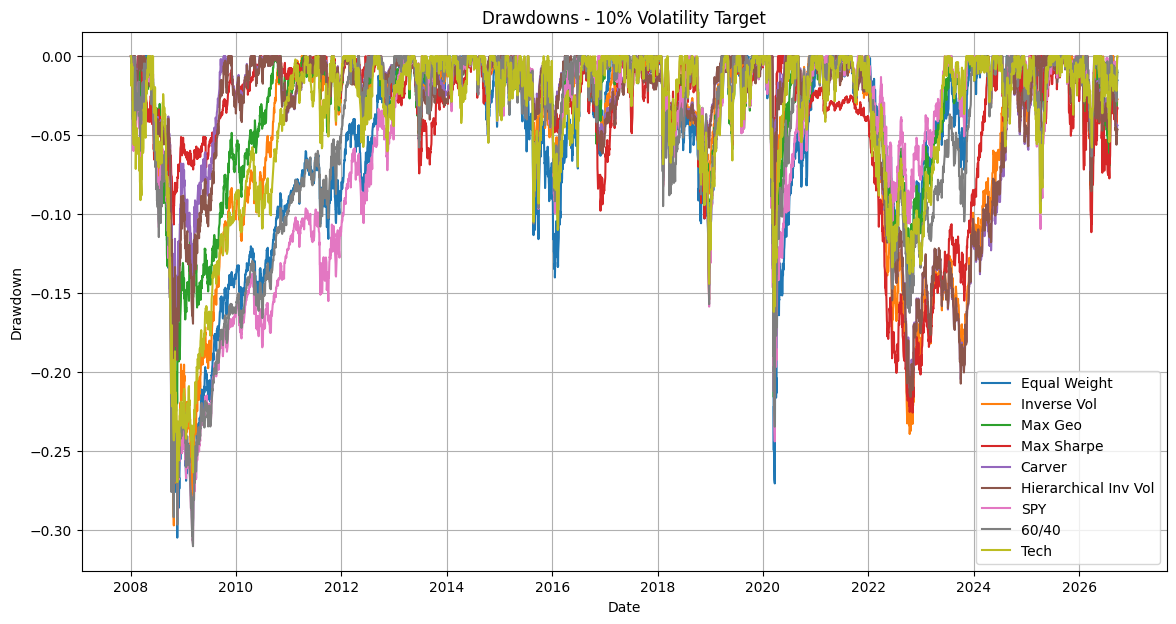

In [3]:
targeted_drawdown = targeted_wealth / targeted_wealth.cummax() - 1

plt.figure(figsize=(14, 7))

for strategy in targeted_drawdown.columns:
    plt.plot(targeted_drawdown.index, targeted_drawdown[strategy], label=strategy)

plt.title("Drawdowns - 10% Volatility Target")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()